In [73]:
import pandas as pd
import rdata
from pathlib import Path

# Folder containing your .RData files
folder_pen = Path("outputc2c3c4c5")

# List all .Rdata files

rdata_files_pen = sorted(folder_pen.glob("*.Rdata"))
all_data_pen_censoradministrative = []
all_data_pen_censornormal = []
all_data_pen_censoruniform = []

for file in rdata_files_pen:
    if "censoradministrative" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoradministrative.append(converted)
    elif "censornormal" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censornormal.append(converted)

/Users/alessandragni/Library/Python/3.9/lib/python/site-packages/rdata/parser/_parser.py:1217: UserWarning: Unknown file type: assumed RDS
  warnings.warn("Unknown file type: assumed RDS")  # noqa: B028
/Users/alessandragni/Library/Python/3.9/lib/python/site-packages/rdata/parser/_parser.py:1220: UserWarning: Wrong extension .Rdata for file in RDS format
  warnings.warn(f"Wrong extension {extension} for file in RDS format")  # noqa: B028


In [75]:
import pandas as pd
import numpy as np

records = []

for d in all_data_pen_censoradministrative:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "n_components": float(d["n_components"][0]),
        "S": d["S"],
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'administrative',
        "silhouette": float(d["silhouette"]['si.summary.Mean'][0])
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

for d in all_data_pen_censornormal:
    record = {
        "seed": float(d["seed"][0]),
        "c": float(d["c"][0]),
        "k": float(d["k"][0]),
        "gammapar": float(d["gammapar"][0]),
        "n_components": float(d["n_components"][0]),
        "S": d["S"],
        "loglik": float(d["loglik"][0]),
        "iterations": float(d["iterations"][0]),
        "lambdaoptim": float(d["lambdaoptim"][0]),
        "censor": 'normal',
        "silhouette": float(d["silhouette"]['si.summary.Mean'][0])
    }

    # expand the estimates into individual columns
    for i, val in enumerate(d["estimate"]):
        record[f"estimate_{i}"] = float(val)

    records.append(record)

# build dataframe
df_pen = pd.DataFrame(records)
df_pen


,seed,c,k,gammapar,n_components,S,loglik,iterations,lambdaoptim,censor,silhouette,estimate_0,estimate_1,estimate_2,estimate_3
0,0.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.09633745720234778, 0.0...",-793.950589,3.0,694.444444,administrative,0.682282,1.060280,2.527421,0.000009,0.704208
1,0.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.09537755357401805, 0.0...",-793.949225,3.0,1000.000000,administrative,0.840600,1.061340,2.526761,0.000009,0.704051
2,0.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.09537755357401805, 0.0...",-793.948962,25.0,83.359641,administrative,0.715008,1.061340,2.526761,0.000009,0.704051
3,0.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.12287969637288218, 0.0...",-793.948920,22.0,79.436508,administrative,0.623981,1.061340,2.526761,0.000009,0.704051
4,10.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2927816...",-886.886635,3.0,694.444444,administrative,0.660967,0.613794,2.462098,0.000012,0.683033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,99.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-1037.191852,30.0,378.099866,normal,0.597595,0.834949,2.543843,0.000008,0.700191
796,9.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-926.502097,3.0,694.444444,normal,0.658611,0.621155,2.585118,0.000006,0.724224
797,9.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-926.522725,3.0,1440.000000,normal,0.782992,0.620930,2.584001,0.000006,0.723861
798,9.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-926.523759,37.0,1078.758401,normal,0.676511,0.620604,2.584172,0.000006,0.723932


### now we transform back the estimate_2 which is $\xi^\rho$ to make \xi

In [76]:
df_pen['estimate_2'] = df_pen['estimate_2']**(1/df_pen['estimate_1'])

In [125]:
df = df_pen

In [126]:
df_pen[df_pen.k == 20].groupby(['k'])['iterations'].value_counts()

k     iterations
20.0  3.0           262
      200.0          41
      31.0           31
      32.0           31
      30.0           25
      29.0           23
      33.0           22
      26.0           20
      38.0           20
      21.0           19
      34.0           19
      35.0           19
      37.0           19
      28.0           18
      36.0           17
      24.0           16
      23.0           15
      25.0           15
      40.0           15
      27.0           14
      39.0           14
      22.0           13
      4.0            12
      18.0           12
      20.0           12
      41.0           11
      16.0           10
      44.0            7
      14.0            6
      15.0            6
      19.0            6
      17.0            5
      11.0            4
      42.0            3
      45.0            3
      46.0            3
      43.0            2
      48.0            2
      65.0            2
      8.0             1
      13.0            1

In [127]:
df.n_components.value_counts()

n_components
3.0    241
5.0    200
4.0    199
2.0    160
Name: count, dtype: int64

In [128]:
df.loc[df.gammapar!=0, 'n_components'].value_counts()

n_components
3.0    241
5.0    200
4.0    199
2.0    160
Name: count, dtype: int64

In [129]:
df = df.loc[(df['censor'] == 'normal')]

In [130]:
df.columns

Index(['seed', 'c', 'k', 'gammapar', 'n_components', 'S', 'loglik',
       'iterations', 'lambdaoptim', 'censor', 'silhouette', 'estimate_0',
       'estimate_1', 'estimate_2', 'estimate_3'],
      dtype='object')

In [131]:
df2 = df.loc[(df['c'] == 2) & (df['n_components'] == 2)]
df2

,seed,c,k,gammapar,n_components,S,loglik,iterations,lambdaoptim,censor,silhouette,estimate_0,estimate_1,estimate_2,estimate_3
400,0.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.2322726331895347, 0.0,...",-935.783889,41.0,1274.619647,normal,0.603982,1.034381,2.475448,0.010109,0.686214
404,10.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.20052779232172296...",-987.144318,3.0,694.444444,normal,0.653466,0.631399,2.461693,0.009933,0.684367
408,11.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-975.343669,3.0,1000.000000,normal,0.671163,0.713949,2.477262,0.010176,0.696305
412,12.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.408587114742421, 0.0, 0.0, 0.0, 0.0, ...",-910.361867,3.0,1000.000000,normal,0.646507,0.013522,2.526569,0.008487,0.716161
416,13.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-900.547976,3.0,694.444444,normal,0.666780,0.246921,2.473786,0.010043,0.695125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,95.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-907.472329,3.0,694.444444,normal,0.650689,0.944970,2.488623,0.009832,0.701597
780,96.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5790498...",-1004.932542,4.0,1.160504,normal,0.658595,0.390891,2.378424,0.009703,0.657481
788,98.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-909.570089,3.0,1000.000000,normal,0.665834,0.210566,2.481464,0.010286,0.692017
792,99.0,2.0,20.0,0.0001,2.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-1037.191167,3.0,1000.000000,normal,0.638331,0.834949,2.543843,0.009957,0.700191


In [132]:
df3 = df.loc[(df['c'] == 3) & (df['n_components'] == 3)]
df3

,seed,c,k,gammapar,n_components,S,loglik,iterations,lambdaoptim,censor,silhouette,estimate_0,estimate_1,estimate_2,estimate_3
401,0.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.21143434653261126, 0.0...",-935.685750,3.0,1440.000000,normal,0.797117,1.034331,2.476860,0.010112,0.686636
405,10.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.20590374326625205...",-987.140057,3.0,1440.000000,normal,0.810135,0.631861,2.461446,0.009928,0.684299
409,11.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-975.339361,3.0,1440.000000,normal,0.803389,0.714264,2.478150,0.010178,0.696560
413,12.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.4085097827123934, 0.0, 0.0, 0.0, 0.0,...",-910.360578,3.0,1440.000000,normal,0.802576,0.013469,2.526833,0.008487,0.716207
417,13.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-900.524156,3.0,1440.000000,normal,0.812709,0.248062,2.473308,0.010042,0.695076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,96.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5790157...",-1004.935854,3.0,1000.000000,normal,0.813378,0.390498,2.378197,0.009704,0.657384
785,97.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.4489783789581502, 0.0, 0.0, 0.0, 0.0,...",-924.782979,3.0,1000.000000,normal,0.818898,0.094560,2.374427,0.009341,0.673884
789,98.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-909.569281,38.0,491.562746,normal,0.584897,0.210566,2.481464,0.010286,0.692017
793,99.0,3.0,20.0,0.0001,3.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-1037.191172,3.0,1000.000000,normal,0.793879,0.834949,2.543843,0.009957,0.700191


In [133]:
df4 = df.loc[(df['c'] == 4) & (df['n_components'] == 4)]
df4

,seed,c,k,gammapar,n_components,S,loglik,iterations,lambdaoptim,censor,silhouette,estimate_0,estimate_1,estimate_2,estimate_3
402,0.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.2291569655554892, 0.0,...",-935.784675,31.0,320.184447,normal,0.536145,1.032851,2.475393,0.010112,0.686198
406,10.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.19856772441249204...",-987.145227,31.0,257.468806,normal,0.490424,0.631006,2.460640,0.009931,0.684040
410,11.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-975.342388,38.0,1059.937097,normal,0.534833,0.713949,2.477262,0.010176,0.696305
414,12.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.4088979943743503, 0.0, 0.0, 0.0, 0.0,...",-910.346846,31.0,343.063793,normal,0.679767,0.013498,2.527174,0.008488,0.716286
418,13.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-900.540576,36.0,748.065478,normal,0.365448,0.247433,2.473474,0.010044,0.695075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782,96.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5790526...",-1004.931010,23.0,63.975508,normal,0.715639,0.390877,2.378424,0.009703,0.657482
786,97.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.4491439988841622, 0.0, 0.0, 0.0, 0.0,...",-924.785475,15.0,15.682354,normal,0.707707,0.094417,2.373775,0.009342,0.673670
790,98.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-909.567506,35.0,485.667382,normal,0.480986,0.210566,2.481464,0.010286,0.692017
794,99.0,4.0,20.0,0.0001,4.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-1037.191869,32.0,378.098058,normal,0.676128,0.834949,2.543843,0.009957,0.700191


In [134]:
df5 = df.loc[(df['c'] == 5) & (df['n_components'] == 5)]
df5

,seed,c,k,gammapar,n_components,S,loglik,iterations,lambdaoptim,censor,silhouette,estimate_0,estimate_1,estimate_2,estimate_3
403,0.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.2291226322425786, 0.0,...",-935.785216,29.0,334.640459,normal,0.447108,1.032851,2.475393,0.010112,0.686198
407,10.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.2005272307137746,...",-987.144537,29.0,299.374332,normal,0.404928,0.631399,2.461693,0.009933,0.684367
411,11.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-975.342737,31.0,455.298232,normal,0.438141,0.713949,2.477262,0.010176,0.696305
415,12.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.4086053302311394, 0.0, 0.0, 0.0, 0.0,...",-910.363680,29.0,337.879532,normal,0.602023,0.013498,2.526504,0.008487,0.716132
419,13.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-900.540379,34.0,759.604786,normal,0.265046,0.247437,2.473814,0.010043,0.695187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,96.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5790554...",-1004.929705,23.0,100.041526,normal,0.603810,0.391009,2.378417,0.009703,0.657484
787,97.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.449205394453603, 0.0, 0.0, 0.0, 0.0, ...",-924.785950,21.0,71.684054,normal,0.626169,0.094982,2.373570,0.009341,0.673691
791,98.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-909.567381,32.0,540.038781,normal,0.391657,0.210566,2.481464,0.010286,0.692017
795,99.0,5.0,20.0,0.0001,5.0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",-1037.191852,30.0,378.099866,normal,0.597595,0.834949,2.543843,0.009957,0.700191


In [ ]:
for df in [df2, df3, df4, df5]:
    print('Mean:')
    print(round(df['silhouette'].mean(),3))
    print('Median:')
    print(round(df['silhouette'].median(),3))
    print('SD:')
    print(round(df['silhouette'].std(),3))
    print('Min:')
    print(round(df['silhouette'].min(),3))
    print('\n')

Mean:
0.618
Median:
0.649
SD:
0.082
Min:
0.309


Mean:
0.67
Median:
0.789
SD:
0.182
Min:
0.055


Mean:
0.541
Median:
0.577
SD:
0.173
Min:
0.134


Mean:
0.466
Median:
0.484
SD:
0.145
Min:
0.089




In [29]:
df4["S"].iloc[0].shape

df4["S"].iloc[0]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.53106304,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.53106304, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [107]:
import numpy as np

def von_neumann_entropy(S):
    # Degree matrix
    d = S.sum(axis=1)
    L = np.diag(d) - S

    # Normalize: density matrix
    tr = np.trace(L)
    if tr == 0:
        return 0.0
    rho = L / tr

    # Eigenvalues
    vals = np.linalg.eigvalsh(rho)

    # Remove zeros (log(0) undefined)
    vals = vals[vals > 1e-12]

    return -np.sum(vals * np.log(vals))

def algebraic_connectivity(S):
    d = S.sum(axis=1)
    L = np.diag(d) - S
    eigs = np.linalg.eigvalsh(L)
    return eigs[1]

def graph_energy(S):
    eigs = np.linalg.eigvals(S)
    return np.sum(np.abs(eigs))


def effective_rank(S):
    u, s, vh = np.linalg.svd(S)
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p + 1e-12)))


In [ ]:
df4["graphen"] = df4["S"].apply(graph_energy)
df3["graphen"] = df3["S"].apply(graph_energy)
df2["graphen"] = df2["S"].apply(graph_energy)

In [105]:
df5["graphen"] = df5["S"].apply(graph_energy)

In [24]:
import numpy as np

def stiefel_dim(N, c): # for F
    return N*c - (c*(c+1))//2

# your fixed parameters (example – replace appropriately)
k_fixed = 1 + 1 + 2 #  k_beta + k_theta + k_baseline
N = 500

def total_params(N, c):
    return k_fixed + stiefel_dim(N, c)

def compute_bic(df, N, c):
    k = total_params(N, c)
    bic = -2 * df["loglik"] + k * np.log(N)
    return bic


In [25]:
compute_bic(df2, N, c=2)

0      7808.723885
3      7994.595977
9      7767.252905
12     7714.299507
15     8009.175273
          ...     
276    8008.095209
279    7897.084274
282    7797.873815
285    7957.762203
291    7764.719241
Name: loglik, Length: 67, dtype: float64

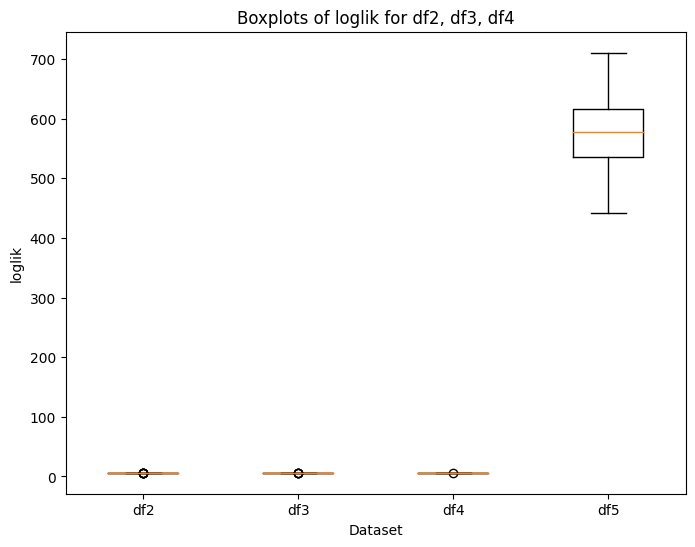

In [ ]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(8, 6))

# Collect loglik values from each dataset
data = [
    # compute_bic(df2, N, c=2),
    # compute_bic(df3, N, c=3),
    # compute_bic(df4, N, c=4)
    df2['graphen'], #graphen
    df3['graphen'],
    df4['graphen'],
    df5['graphen']
    df2['silhouette'], #graphen
    df3['silhouette'],
    df4['silhouette'],
    df5['silhouette']
]

# Labels for the boxplots
labels = ['df2', 'df3', 'df4', 'df5']

# Generate the boxplot
plt.boxplot(data, labels=labels)

plt.xlabel('Dataset')
plt.ylabel('loglik')
plt.title('Boxplots of loglik for df2, df3, df4')

plt.show()


In [193]:
df2['graphen'].median()

581.1246125233296

In [194]:
df3['graphen'].median()

588.4184447893169

In [195]:
df4['graphen'].median()

583.9014094281295

## Bias of estimators

In [289]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# True parameter values
true_values = {
    'estimate_0': 0.5,
    'estimate_1': 2.5,
    'estimate_2': 0.01,
    'estimate_3': np.log(2)
}

# Define descriptive titles for each estimate
titles = {
    'estimate_0': r"(i) $1/\alpha$", # r"Var$(u_g)$",
    'estimate_1': r"(ii) $\rho$",
    'estimate_2': r"(iii) $\xi$",
    'estimate_3': r"(iv) $\beta$"
}

TITLE_SIZE = 16
LABEL_SIZE = 12
TICK_SIZE  = 13

estimates = list(titles.keys())

for j in ['administrative', 'normal']:
    
    fig, axes = plt.subplots(
        1, len(estimates),
        figsize=(4.2 * len(estimates), 4.7),
        sharey=False
    )

    for ax, est in zip(axes, estimates):

        # Filter & convert
        dfx = df.loc[df.censor == j, [est, 'gammapar']].apply(pd.to_numeric, errors='coerce')
        
        sns.boxplot(
            data=dfx,
            x="gammapar",
            y=est,
            hue="gammapar",
            palette="Greys",
            dodge=False,  
            ax=ax
        )

        # True value
        ax.axhline(
            y=true_values[est],
            color='red',
            linestyle='--',
            label="True value"
        )

        # Clean subplot
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(f"{titles[est]}", fontsize=TITLE_SIZE)

        # REMOVE subplot legend (keep only global one)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()

    fig.subplots_adjust(bottom=0.15, top=0.8)

    fig.legend(
        handles, labels,
        title=r"$\gamma$",
        loc="lower center",
        ncol=len(labels),
        fontsize=TICK_SIZE,
        title_fontsize=TICK_SIZE
    )


    # Global title
    plt.suptitle(
        rf"Estimates $\hat{{p}}$ – {j} censoring",
        fontsize=TITLE_SIZE
    )

    fig.subplots_adjust(top=0.85, bottom=0.18)
    plt.savefig(f"Plots/Estimates_{j}.pdf", bbox_inches="tight")
    plt.close()


In [290]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib.ticker import ScalarFormatter

# # Modern clean style
# sns.set_style("whitegrid")
# #sns.set_context("talk")  

# # Define the true values for each estimate
# true_values = {
#     'estimate_0': 0.5,
#     'estimate_1': 2.5,
#     'estimate_2': 0.01,
#     'estimate_3': np.log(2)
# }

# # Define descriptive titles for each estimate
# titles = {
#     'estimate_0': r"(i) $1/\alpha$", # r"Var$(u_g)$",
#     'estimate_1': r"(ii) $\rho$",
#     'estimate_2': r"(iii) $\xi$",
#     'estimate_3': r"(iv) $\beta$"
# }

# numb = {
#     'estimate_0': "(i)",
#     'estimate_1': "(ii)",
#     'estimate_2': "(iii)",
#     'estimate_3': "(iv)"
# }


# # Consistent style parameters
# TITLE_SIZE = 22
# LABEL_SIZE = 18
# TICK_SIZE  = 16


# for j in ['administrative', 'normal', 'uniform']:
#     for i in ['estimate_0', 'estimate_1', 'estimate_2', 'estimate_3']:
#         cols = [i, 'gammapar']
#         dfx = df.loc[df.censor==j, cols].apply(pd.to_numeric, errors='coerce')

#         # Plot using seaborn boxplot
#         plt.figure(figsize=(5.5, 6))
#         sns.boxplot(data=dfx, x='gammapar', y=i, palette='Greys')
        
#         # Overlay the true value as a horizontal line
#         plt.axhline(y=true_values[i], color='red', linestyle='--', label='True Value')

#         # Bigger text everywhere
#         plt.title(f"{numb[i]} {titles[i]} - {j} cens.", fontsize=TITLE_SIZE)
#         plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#         plt.ylabel(titles[i], fontsize=LABEL_SIZE)
#         plt.xticks(fontsize=TICK_SIZE)
#         plt.yticks(fontsize=TICK_SIZE)

#         #____
#         # get the tick locations (categories)
#         ax = plt.gca()
#         ticks = ax.get_xticks()

#         # original values from the dataframe
#         vals = dfx['gammapar'].unique()

#         # Sort to match seaborn order
#         vals = np.sort(vals)

#         # Create formatted labels
#         labels = []
#         for x in vals:
#             if x == 0:
#                 labels.append("0")
#             elif abs(x) < 0.01:
#                 exp = int(np.floor(np.log10(abs(x))))
#                 labels.append(rf"$10^{{{exp}}}$")
#             else:
#                 labels.append(f"{x:g}")

#         # Apply them
#         ax.set_xticklabels(labels, fontsize=TICK_SIZE)
#         #_________

#         # plt.show()
        
#         # Adjust legend so it shows only the true value
#         #plt.legend([f'True Value: {true_values[i]}'], loc='best')
        
#         plt.subplots_adjust(top=0.90, bottom=0.15)

#         # add enough space on the left so the y-label is fully visible
#         plt.gcf().subplots_adjust(left=0.2)

#         # Save the figure (PDF for LaTeX)
#         plt.savefig(f"Plots/Distribution_{j}_{i}.pdf", pad_inches=0.1)
#         plt.close()

        
    


## Bias-variance trade-off

In [291]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

for j in ['administrative', 'normal']:
    dfx = df[df.censor == j].copy()

    #_____________________
    # MSE

    # Define the true values for each estimate
    truevals = np.array([0.5, 2.5, 0.001, np.log(2)])

    # Compute L2 squared differences for each beta
    for i in range(4):
        dfx[f'diff_{i}'] = (dfx[f'estimate_{i}'] - truevals[i])**2

    # Melt dataframe to long format for plotting
    df_long = dfx.melt(
        id_vars=['gammapar'], 
        value_vars=['diff_0', 'diff_1', 'diff_2', 'diff_3'],
        var_name='Beta', 
        value_name='SquaredError'
    )

    # Clean up Beta names
    df_long['Beta'] = df_long['Beta'].map({'diff_0': r"(i) $1/\alpha$", 'diff_1': r"(ii) $\rho$", 'diff_2': r"(iii) $\xi$", 'diff_3': r"(iv) $\beta$"})

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))

    # OLD VERSION
    # sns.boxplot(data=df_long, x='Beta', y='SquaredError', hue='gammapar', palette='Greys')
    # plt.title(f"(i) MSE  - {j} censoring", fontsize=TITLE_SIZE)
    # plt.xlabel("", fontsize=LABEL_SIZE)
    # plt.ylabel(r"$\|\hat{p} - p\|_2^2$", fontsize=LABEL_SIZE)

    # plt.xticks(fontsize=TICK_SIZE)
    # plt.yticks(fontsize=TICK_SIZE)

    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    # plt.legend(title=r'$\gamma$', fontsize=TICK_SIZE-3, title_fontsize=LABEL_SIZE-3)

    # # Save the figure (PDF for LaTeX)
    # plt.savefig(f"Plots/fig_MSE_{j}.pdf", bbox_inches="tight")
    # plt.close()

    # plt.show()


    betas = df_long['Beta'].unique()

    fig, axes = plt.subplots(
        1, len(betas),
        figsize=(4 * len(betas), 4.7),
        sharey=False
    )

    if len(betas) == 1:
        axes = [axes]

    for ax, beta in zip(axes, betas):
        df_sub = df_long[df_long['Beta'] == beta]

        sns.boxplot(
            data=df_sub,
            x="Beta",
            y="SquaredError",
            hue="gammapar",
            palette="Greys",
            ax=ax
        )

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(beta, fontsize=TITLE_SIZE)

        # Remove legend in each subplot
        ax.get_legend().remove()

        handles, labels = axes[0].get_legend_handles_labels()

        fig.subplots_adjust(bottom=0.2, top=0.82)

        fig.legend(
            handles, labels,
            title=r"$\gamma$",
            loc="lower center",
            ncol=len(labels),
            fontsize=TICK_SIZE,
            title_fontsize=TICK_SIZE
        )

    plt.suptitle(
        rf"MSE $\|\hat{{p}} - p\|_2^2$ - {j} censoring",
        fontsize=TITLE_SIZE
    )

    # plt.show()
    # Save figure
    plt.savefig(f"Plots/fig_MSE_{j}.pdf", bbox_inches="tight")
    plt.close()



    #_____________________
    # VARIANCE

    # Keep relevant columns
    df_true = dfx[['seed', 'gammapar', 'estimate_0', 'estimate_1', 'estimate_2', 'estimate_3']].copy()

    # --- Compute squared deviations by gammapar ---
    for i in range(4):
        col = f'estimate_{i}'
        # Compute mean per gammapar group
        df_true[f'{col}_mean'] = df_true.groupby('gammapar')[col].transform('mean')
        # Compute squared deviation from that mean
        df_true[f'{col}'] = (df_true[col] - df_true[f'{col}_mean'])**2

    # --- Melt to long format for plotting ---
    df_long = df_true.melt(
        id_vars=['gammapar'],
        value_vars=['estimate_0', 'estimate_1', 'estimate_2', 'estimate_3'],
        var_name='Beta',
        value_name='SquaredDeviation'
    )

    # Clean up Beta names
    df_long['Beta'] = df_long['Beta'].map(titles)

    # --- Plotting ---
    plt.figure(figsize=(6, 6))
    # OLD VERSION
    # sns.boxplot(data=df_long, x='Beta', y='SquaredDeviation', hue='gammapar', palette='Greys')

    #**********************************************
    # Get unique parameters in the order you want
    betas = df_long['Beta'].unique()

    # One subplot per Beta
    fig, axes = plt.subplots(1, len(betas), figsize=(4 * len(betas), 4.7), sharey=False)

    if len(betas) == 1:
        axes = [axes]  

    for ax, beta in zip(axes, betas):
        df_sub = df_long[df_long['Beta'] == beta]

        sns.boxplot(
            data=df_sub,
            x="Beta",
            y="SquaredDeviation",
            hue="gammapar",
            palette="Greys",
            ax=ax
        )
        ax.set_title(beta)
        ax.set_xlabel("")
        ax.set_ylabel("") #r"$\|\hat{p} - \bar{\hat{p}}\|_2^2$")

        ax.set_xticks([])         # remove tick positions
        ax.set_xticklabels([])    # remove tick labels

        # Title (keep it)
        ax.set_title(beta, fontsize=14)
        ax.get_legend().remove()

    # Move legend outside
    handles, labels = axes[0].get_legend_handles_labels()

    fig.subplots_adjust(bottom=0.2, top=0.82) 
    fig.legend(
        handles, labels, title=r"$\gamma$",
        loc="lower center",
        ncol=len(labels),
        fontsize=TICK_SIZE,
        title_fontsize=TICK_SIZE
        #bbox_to_anchor=(0.5, 0.02) #,   # push legend further down
        #frameon=False
    )

    plt.suptitle(rf"Variance $\|\hat{{p}} - \bar{{\hat{{p}}}}\|_2^2$ - {j} censoring", fontsize=TITLE_SIZE)

    # plt.show()
    # Save the figure (PDF for LaTeX)
    plt.savefig(f"Plots/fig_Variance_{j}.pdf", bbox_inches="tight")
    plt.close()

    #*********************************************

    # OLD VERSION
    # plt.title(f"(ii) Variance - {j} censoring", fontsize=TITLE_SIZE)
    # plt.xlabel("", fontsize=LABEL_SIZE)
    # plt.ylabel(r"$\|\hat{p} - \bar{\hat{p}}\|_2^2$", fontsize=LABEL_SIZE)

    # plt.yticks(fontsize=TICK_SIZE)

    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    # # plt.legend(title=r'$\gamma$', fontsize=TICK_SIZE-3, title_fontsize=LABEL_SIZE-3)

    # # Save the figure (PDF for LaTeX)
    # plt.savefig(f"Plots/fig_Variance_{j}.pdf", bbox_inches="tight")
    # plt.close()

    # plt.show()




<Figure size 1000x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

## Accuracy

In [292]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import rdata
from pathlib import Path

# Folder containing your .RData files
folder_pen = Path("output/penalized")

# List all .Rdata files
rdata_files_pen = sorted(folder_pen.glob("*.Rdata"))
all_data_pen_censoradministrative = []
all_data_pen_censornormal = []
all_data_pen_censoruniform = []


for file in rdata_files_pen:
    if "censoradministrative" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoradministrative.append(converted)
    elif "censornormal" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censornormal.append(converted)
    elif "censoruniform" in str(file):
        parsed = rdata.parser.parse_file(file)
        converted = rdata.conversion.convert(parsed)
        all_data_pen_censoruniform.append(converted)



/Users/alessandragni/Library/Python/3.9/lib/python/site-packages/rdata/parser/_parser.py:1217: UserWarning: Unknown file type: assumed RDS
  warnings.warn("Unknown file type: assumed RDS")  # noqa: B028
/Users/alessandragni/Library/Python/3.9/lib/python/site-packages/rdata/parser/_parser.py:1220: UserWarning: Wrong extension .Rdata for file in RDS format
  warnings.warn(f"Wrong extension {extension} for file in RDS format")  # noqa: B028


In [293]:
def simple_relabel(true_labels, pred_labels):
    """
    Relabel predicted clusters to match true labels based on maximum overlap.
    Works when number of clusters is small (e.g., 3) and you just want names to match.
    """
    true_labels = pd.Series(true_labels)
    pred_labels = pd.Series(pred_labels)
    
    unique_true = true_labels.unique()
    unique_pred = pred_labels.unique()
    
    mapping = {}
    used_true = set()
    
    for p in unique_pred:
        # find the true label with max overlap
        overlaps = {t: ((true_labels==t) & (pred_labels==p)).sum() for t in unique_true if t not in used_true}
        best_true = max(overlaps, key=overlaps.get)
        mapping[p] = best_true
        used_true.add(best_true)
    
    new_preds = pred_labels.map(mapping)
    return new_preds, mapping

In [294]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

gammapars_all = {}
accuracy_all = {}
ari_all = {}
nmi_all = {}

numb = {
    'admin': "(i) Administrative censoring",
    'norm': "(ii) Normal censoring",
    'unif': "(iii) Uniform censoring"
}


for j,name in [(all_data_pen_censoradministrative, "admin"), (all_data_pen_censornormal, "norm"), (all_data_pen_censoruniform, "unif")]:
    datasets = []
    gammapars = []
    for d in j:
        if d["n_components"] == 3 and d["k"] == 20:
            if d['gammapar'] != 0.5:
                datasets.append(pd.DataFrame(d["clusters"]))
                gammapars.append(d["gammapar"][0])

        
    accuracy_list = []
    nmi_list = []
    ari_list = []

    for df in datasets:
        # Extract the two cluster membership columns
        true_labels = df.iloc[:, 0]
        pred_labels = df.iloc[:, 1]

        # Align predicted clusters to true clusters
        aligned_preds, mapping = simple_relabel(true_labels, pred_labels)

        # Add an indicator column for exact matches
        df["same_membership"] = (true_labels == aligned_preds).astype(int)


        # Compute metrics
        nmi = normalized_mutual_info_score(true_labels, aligned_preds)
        print(f"NMI: {nmi:.3f}")
        nmi_list.append(nmi)

        ari = adjusted_rand_score(true_labels, aligned_preds)
        print(f"ARI: {ari:.3f}") 
        ari_list.append(ari)   

        accuracy = df["same_membership"].mean()
        print(f"Accuracy: {accuracy:.3f}")   
        accuracy_list.append(accuracy)

        print('\n')

    
    gammapars_all[f"{name}"] = np.array(gammapars)
    accuracy_all[f"{name}"] = np.array(accuracy_list)
    ari_all[f"{name}"] = np.array(ari_list)
    nmi_all[f"{name}"] = np.array(nmi_list)


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 0.837
ARI: 0.819
Accuracy: 0.928


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 0.713
ARI: 0.583
Accuracy: 0.790


NMI: 0.713
ARI: 0.583
Accuracy: 0.790


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 0.854
ARI: 0.839
Accuracy: 0.942


NMI: 0.854
ARI: 0.839
Accuracy: 0.942


NMI: 0.786
ARI: 0.723
Accuracy: 0.890


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000


NMI: 1.000
ARI: 1.000
Accuracy: 1.000




In [295]:
# for j in ['admin', 'norm', 'unif']:

#     # Create a DataFrame for grouping
#     df_acc = pd.DataFrame({"Accuracy": accuracy_all[j], "Gamma": gammapars_all[j]})

#     plt.figure(figsize=(6, 5))

#     # Use seaborn boxplot with greyscale palette for consistency
#     sns.boxplot(
#         data=df_acc,
#         x="Gamma",
#         y="Accuracy",
#         palette="Greys"
#     )



#     # Styling
#     plt.title(f"{numb[j]}", fontsize=TITLE_SIZE)
#     plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#     plt.ylabel("Accuracy", fontsize=LABEL_SIZE)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.xticks(fontsize=TICK_SIZE)
#     plt.yticks(fontsize=TICK_SIZE)

#     plt.tight_layout()

#     # Save the figure (PDF for LaTeX)
#     plt.savefig(f"Plots/fig_Accuracy_{j}.pdf", bbox_inches="tight")
#     plt.close()



In [296]:
# for j in ['admin', 'norm', 'unif']:

#     # Create a DataFrame for grouping
#     df_acc = pd.DataFrame({"ARI": ari_all[j], "Gamma": gammapars_all[j]})

#     plt.figure(figsize=(6, 5))

#     # Use seaborn boxplot with greyscale palette for consistency
#     sns.boxplot(
#         data=df_acc,
#         x="Gamma",
#         y="ARI",
#         palette="Greys"
#     )

#     # Styling
#     plt.title(f"{numb[j]}", fontsize=TITLE_SIZE)
#     plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#     plt.ylabel("ARI", fontsize=LABEL_SIZE)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.xticks(fontsize=TICK_SIZE)
#     plt.yticks(fontsize=TICK_SIZE)

#     plt.tight_layout()

#     # Save the figure (PDF for LaTeX)
#     plt.savefig(f"Plots/fig_ARI_{j}.pdf", bbox_inches="tight")
#     plt.close()

In [297]:
# for j in ['admin', 'norm', 'unif']:

#     # Create a DataFrame for grouping
#     df_acc = pd.DataFrame({"NMI": nmi_all[j], "Gamma": gammapars_all[j]})

#     plt.figure(figsize=(6, 5))

#     # Use seaborn boxplot with greyscale palette for consistency
#     sns.boxplot(
#         data=df_acc,
#         x="Gamma",
#         y="NMI",
#         palette="Greys"
#     )


#     # Styling
#     plt.title(f"{numb[j]}", fontsize=TITLE_SIZE)
#     plt.xlabel(r"$\gamma$", fontsize=LABEL_SIZE)
#     plt.ylabel("NMI", fontsize=LABEL_SIZE)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.xticks(fontsize=TICK_SIZE)
#     plt.yticks(fontsize=TICK_SIZE)

#     plt.tight_layout()

#     # Save the figure (PDF for LaTeX)
#     plt.savefig(f"Plots/fig_NMI_{j}.pdf", bbox_inches="tight")
#     plt.close()

In [298]:
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

titles_acc = {
    'admin': "(i) Accuracy – Administrative cens.",
    'norm':  "(ii) Accuracy – Normal cens.",
}

titles_ari = {
    'admin': "(iii) ARI – Administrative cens.",
    'norm':  "(iv) ARI – Normal cens.",
}

# -------------------------------
# Create 2×2 figure
# -------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

# store gamma values once
gammas_used = None

# --------------------------------
# First row: ACCURACY
# --------------------------------
for col, j in enumerate(['admin', 'norm']):

    df_acc = pd.DataFrame({
        "Value": accuracy_all[j],
        "Gamma": gammapars_all[j]
    })

    if gammas_used is None:
        gammas_used = np.sort(df_acc["Gamma"].unique())

    sns.boxplot(
        data=df_acc,
        x="Gamma",
        y="Value",
        palette="Greys",
        ax=axes[col]
    )

    ax = axes[col]
    ax.set_title(titles_acc[j], fontsize=TITLE_SIZE-5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_xticklabels([])

# --------------------------------
# Second row: ARI
# --------------------------------
for col, j in enumerate(['admin', 'norm']):

    df_ari = pd.DataFrame({
        "Value": ari_all[j],        # your ARI values here
        "Gamma": gammapars_all[j]
    })

    sns.boxplot(
        data=df_ari,
        x="Gamma",
        y="Value",
        palette="Greys",
        ax=axes[col+2]
    )

    ax = axes[col+2]
    ax.set_title(titles_ari[j], fontsize=TITLE_SIZE-5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_xticklabels([])

# --------------------------------
# Build the global gamma legend
# --------------------------------
colors = sns.color_palette("Greys", len(gammas_used))

labels = []
for g in gammas_used:
    if g == 0:
        labels.append("0")
    elif abs(g) < 0.01:
        e = int(np.floor(np.log10(abs(g))))
        labels.append(rf"$10^{{{e}}}$")
    else:
        labels.append(f"{g:g}")

handles = [
    mpatches.Patch(facecolor=colors[k], label=labels[k], 
                   edgecolor="black",  
                   linewidth=0.5)
    for k in range(len(gammas_used))
]

fig.legend(
    handles,
    labels,
    title=r"$\gamma$",
    loc="lower center",
    ncol=len(labels),
    fontsize=TICK_SIZE,
    title_fontsize=TICK_SIZE
)

# Add spacing and global title
fig.subplots_adjust(top=0.85, bottom=0.28)

#fig.suptitle("Accuracy and ARI – Censoring Comparison", fontsize=TITLE_SIZE)

plt.savefig("Plots/Fig_Accuracy_ARI_All.pdf", bbox_inches="tight")
plt.close()
